In [ ]:
import numpy as np
import glob
import os
from datetime import datetime
from datetime import timedelta
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
import cartopy.crs as ccrs
import cartopy.feature as cft
import pickle

Plot the temporal evolution of the spatial maps of UTCI hot spots (with values in °C and stress categories), UTCI cool spots (with values in °C and stress categories), and MRT (average of the 6 MRT values and their standard deviation) - Figures 10, S14, S16

In [ ]:
#code to extract variables of interest from LCZ, WSF-MB, and Geoscape cases

# Constants
Rd = 287.05  # J/kg/K

# file paths
paths = {
    "LCZ": "/g/data/fy29/mf9078/run_WRF/etamodified/output/1out/animation/",
    "WSF-MB": "/g/data/fy29/mf9078/run_WRF/etamodified/output/3out/animation/",
    "Geoscape": "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/"
}

# Define diurnal periods
periods = {
    'bsr': {'hours': list(range(2, 6)), 'first_hour': 2},      # 2-5 am: before sunrise
    'morning': {'hours': list(range(7, 11)), 'first_hour': 7}, # 7-10 am: morning
    'peak': {'hours': list(range(11, 15)), 'first_hour': 11},  # 11 am-2 pm: peak solar heating
    'aft': {'hours': list(range(15, 19)), 'first_hour': 15},   # 3-6 pm: late afternoon
    'eve': {'hours': list(range(19, 23)), 'first_hour': 19}    # 7-10 pm: evening
}

# Dictionary to store results for each scenario, period, and variable
results = {}

# Loop through all the scenarios
for label, sc_path in paths.items():
    file_list = sorted(glob.glob(os.path.join(sc_path, "wrfout_d02_2017-01-*")))
    
    # Initialize results structure for this scenario
    results[label] = {}
    
    # Initialize for each period
    for period_name in periods.keys():
        results[label][period_name] = {'var_sums': {}, 'n': 0}
    
    # Loop through files
    for fpath in file_list:
        ds = xr.open_dataset(fpath)
        
        # Parse timestamp and convert to AEST
        timestamp_utc = datetime.strptime(os.path.basename(fpath)[11:], "%Y-%m-%d_%H:%M:%S")
        timestamp_aest = timestamp_utc + timedelta(hours=10)
        
        # Extract all variables (only if we're in one of our time periods)
        current_hour = timestamp_aest.hour
        for period_name, period_info in periods.items():
            if current_hour in period_info['hours']:
                # Extract TMR variables
                tmr_11 = ds["TMR_11"]
                tmr_12 = ds["TMR_12"]
                tmr_13 = ds["TMR_13"]
                tmr_21 = ds["TMR_21"]
                tmr_22 = ds["TMR_22"]
                tmr_23 = ds["TMR_23"]
                
                # Stack all TMR variables along a new dimension for easier max/min calculation
                # Create a 4D array: [time, south_north, west_east, tmr_components]
                tmr_stack = xr.concat([tmr_11, tmr_12, tmr_13, tmr_21, tmr_22, tmr_23], 
                                    dim='tmr_component')
                
                # Calculate TMR_max and TMR_min (ignoring NaN values)
                tmr_max = tmr_stack.max(dim='tmr_component', skipna=True)
                tmr_min = tmr_stack.min(dim='tmr_component', skipna=True)
                
                # Where all TMR values are NaN, the result should also be NaN
                # Check if all TMR values are NaN for each grid point
                all_nan_mask = tmr_stack.isnull().all(dim='tmr_component')
                tmr_max = tmr_max.where(~all_nan_mask)
                tmr_min = tmr_min.where(~all_nan_mask)
                
                # Calculate TMR mean and std (existing code)
                tmr_mean = tmr_stack.mean(dim='tmr_component', skipna=True)
                tmr_mean = tmr_mean.where(~all_nan_mask)  # Set to NaN where all TMR values are NaN
                
                # Standard deviation calculation
                tmr_std = tmr_stack.std(dim='tmr_component', skipna=True)
                tmr_std = tmr_std.where(~all_nan_mask)  # Set to NaN where all TMR values are NaN
                
                variables = {
                    'TMR_11': tmr_11,
                    'COMF90': ds["COMF_90"],
                    'COMF10': ds["COMF_10"],
                    'TMR12': tmr_12,
                    'TMR13': tmr_13,
                    'TMR21': tmr_21,
                    'TMR22': tmr_22,
                    'TMR23': tmr_23,
                    'TMR_mean': tmr_mean,
                    'TMR_std': tmr_std,
                    'TMR_max': tmr_max,  # New variable
                    'TMR_min': tmr_min   # New variable
                }
                
                # First entry for this period or accumulate
                is_first_entry = (timestamp_aest.day == 10 and current_hour == period_info['first_hour'])
                
                if is_first_entry:
                    results[label][period_name]['var_sums'] = {key: val for key, val in variables.items()}
                    results[label][period_name]['n'] = 1
                else:
                    # Only accumulate if we already have data for this period
                    if results[label][period_name]['var_sums']:
                        for key, val in variables.items():
                            results[label][period_name]['var_sums'][key] += val
                        results[label][period_name]['n'] += 1
                
                break  # Don't check other periods once we found a match

# Calculate averages and restructure results
final_results = {}
for label in paths.keys():
    final_results[label] = {}
    for period_name in periods.keys():
        final_results[label][period_name] = {}
        if results[label][period_name]['var_sums']:  # Only if we have data
            n = results[label][period_name]['n']
            for var_name, var_sum in results[label][period_name]['var_sums'].items():
                final_results[label][period_name][var_name] = var_sum / n

# Replace the original results dictionary
results = final_results

with open("/g/data/gb02/mf9078/spatialanalysiswithoutdefault.pkl", "wb") as f:
    pickle.dump(results, f) 

In [7]:
with open("/g/data/gb02/mf9078/spatialanalysiswithoutdefault.pkl", "rb") as f:
    results = pickle.load(f) 

In [8]:
# mask
lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

file_luindex = "/g/data/fy29/mf9078/run_WRF/etamodified/output/4out/animation/wrfout_d02_2017-01-12_21:00:00" #any wrfout with 10-category LCZ, i.e., any scenario but bulk

# Initialize on first file to get the subset bounds and mask
ds = xr.open_dataset(file_luindex) 
XLAT = ds["XLAT"]
XLONG = ds["XLONG"]
LU_INDEX = ds["LU_INDEX"]

lat_mask = (XLAT >= lat_min) & (XLAT <= lat_max)
lon_mask = (XLONG >= lon_min) & (XLONG <= lon_max)
lu_mask = (LU_INDEX >= 51) & (LU_INDEX <= 60)
region_mask = lat_mask & lon_mask & lu_mask

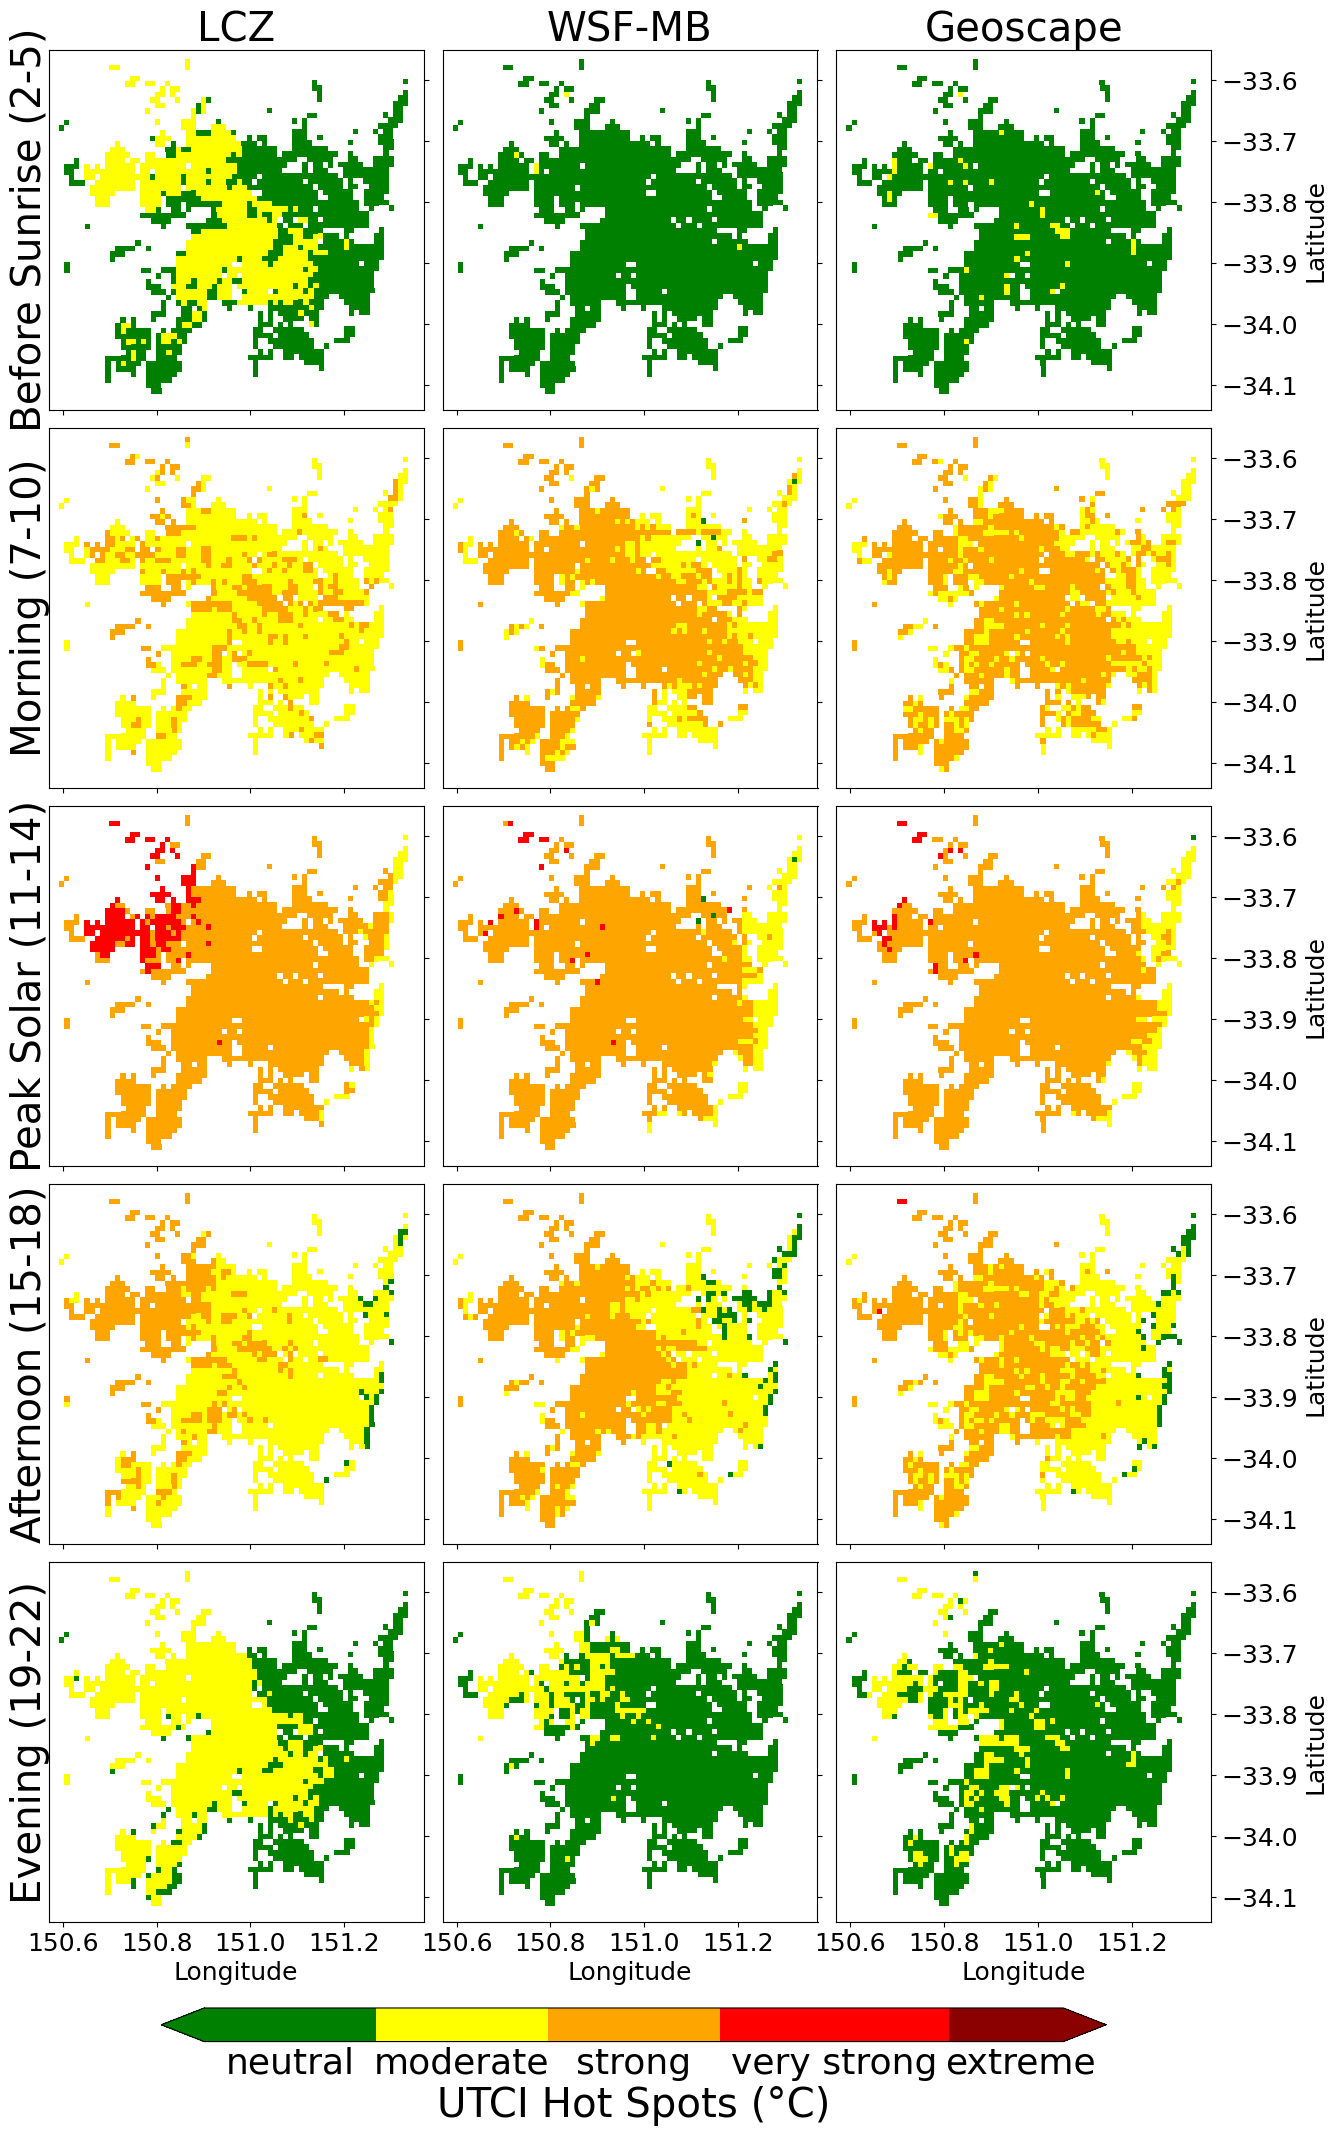

In [ ]:
#UTCI hot spots/COMF90 with stress categories - Figure 10

#custom colorbar
# Define the temperature boundaries and corresponding colors
boundaries = [20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50]
colors = ['green', 'green', 'green', 'yellow', 'yellow', 'yellow', 'orange', 'orange', 'orange', 'red', 'red', 'red', 'red', 'darkred', 'darkred']

# Using ListedColormap for discrete colors
def create_utci_colormap_discrete():
    """Create a discrete colormap with sharp boundaries between colors"""
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(boundaries, cmap.N)
    return cmap, norm
# Get the colormap
utci_cmap, utci_norm = create_utci_colormap_discrete()

# Define scenarios and periods
scenarios = ["LCZ", "WSF-MB", "Geoscape"]
periods = ["bsr", "morning", "peak", "aft", "eve"]
period_labels = {
    "bsr": "Before Sunrise (2-5)",
    "morning": "Morning (7-10)", 
    "peak": "Peak Solar (11-14)",
    "aft": "Afternoon (15-18)",
    "eve": "Evening (19-22)"
}

lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

# Set up figure with 5x3 subplots
fig, axs = plt.subplots(5, 3, figsize=(15, 24), sharex=True, sharey=True, constrained_layout=False)

# Plot data
for row, period in enumerate(periods):
    for col, scenario in enumerate(scenarios):
        ax = axs[row, col]
        
        # Get data for this period and scenario
        data = results[scenario][period]["COMF90"].where(region_mask)
        
        # Plot
        im = data.plot(
            ax=ax,
            x='XLONG',
            y='XLAT',
            cmap=utci_cmap,
            norm=utci_norm,
            add_colorbar=False
        )
        
        # Set limits
        ax.set_ylim(lat_min, lat_max)
        ax.set_xlim(lon_min, lon_max)
                
        # Labels and titles
        if row == 0:  # Top row - add scenario names
            ax.set_title(scenario, fontsize=29)  #, fontweight='bold'
        else:
            ax.set_title("")
            
        if col == 0:  # Left column - add period labels
            ax.text(-0.05, 0.5, period_labels[period], transform=ax.transAxes, 
                   fontsize=29, rotation=90, #fontweight='bold', 
                   verticalalignment='center', horizontalalignment='center')
        
        # X and Y labels only on edges
        if row == len(periods) - 1:  # Bottom row
            ax.set_xlabel("Longitude", fontsize=18)
        else:
            ax.set_xlabel("")
            
        if col == 2:  # Left column
            ax.set_ylabel("Latitude", fontsize=18)
        else:
            ax.set_ylabel("")
            
        # Remove tick labels except on edges
        if row != len(periods) - 1:  # Not bottom row
            ax.tick_params(labelbottom=False)
        if col != 2:  # Not left column
            ax.tick_params(labelleft=False)
        else:
            ax.tick_params(labelleft=True)

        ax.tick_params(axis='both', which='major', labelsize=18)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

# Add single horizontal colorbar at bottom spanning all columns
cax = fig.add_axes([0.2, 0.05, 0.63, 0.014])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', 
                   pad=0.02, shrink=0.8, aspect=40, ticks=boundaries, extend='both')
cbar.set_label("UTCI Hot Spots (°C)", fontsize=29)
cbar.set_ticklabels(boundaries)
tick_locations = [23, 29, 35, 42, 48.5]
tick_labels = ['neutral', 'moderate', 'strong', 'very strong', 'extreme']
cbar.set_ticks(tick_locations)
cbar.set_ticklabels(tick_labels)
cbar.ax.minorticks_off()
cbar.ax.tick_params(size=0, labelsize=26)
fig.subplots_adjust(wspace=0.05, hspace=0.05, bottom=0.1)

plt.savefig("COMF90avg-5x3-all_periods_stresscats.png", 
           bbox_inches='tight', dpi=300)
plt.show()

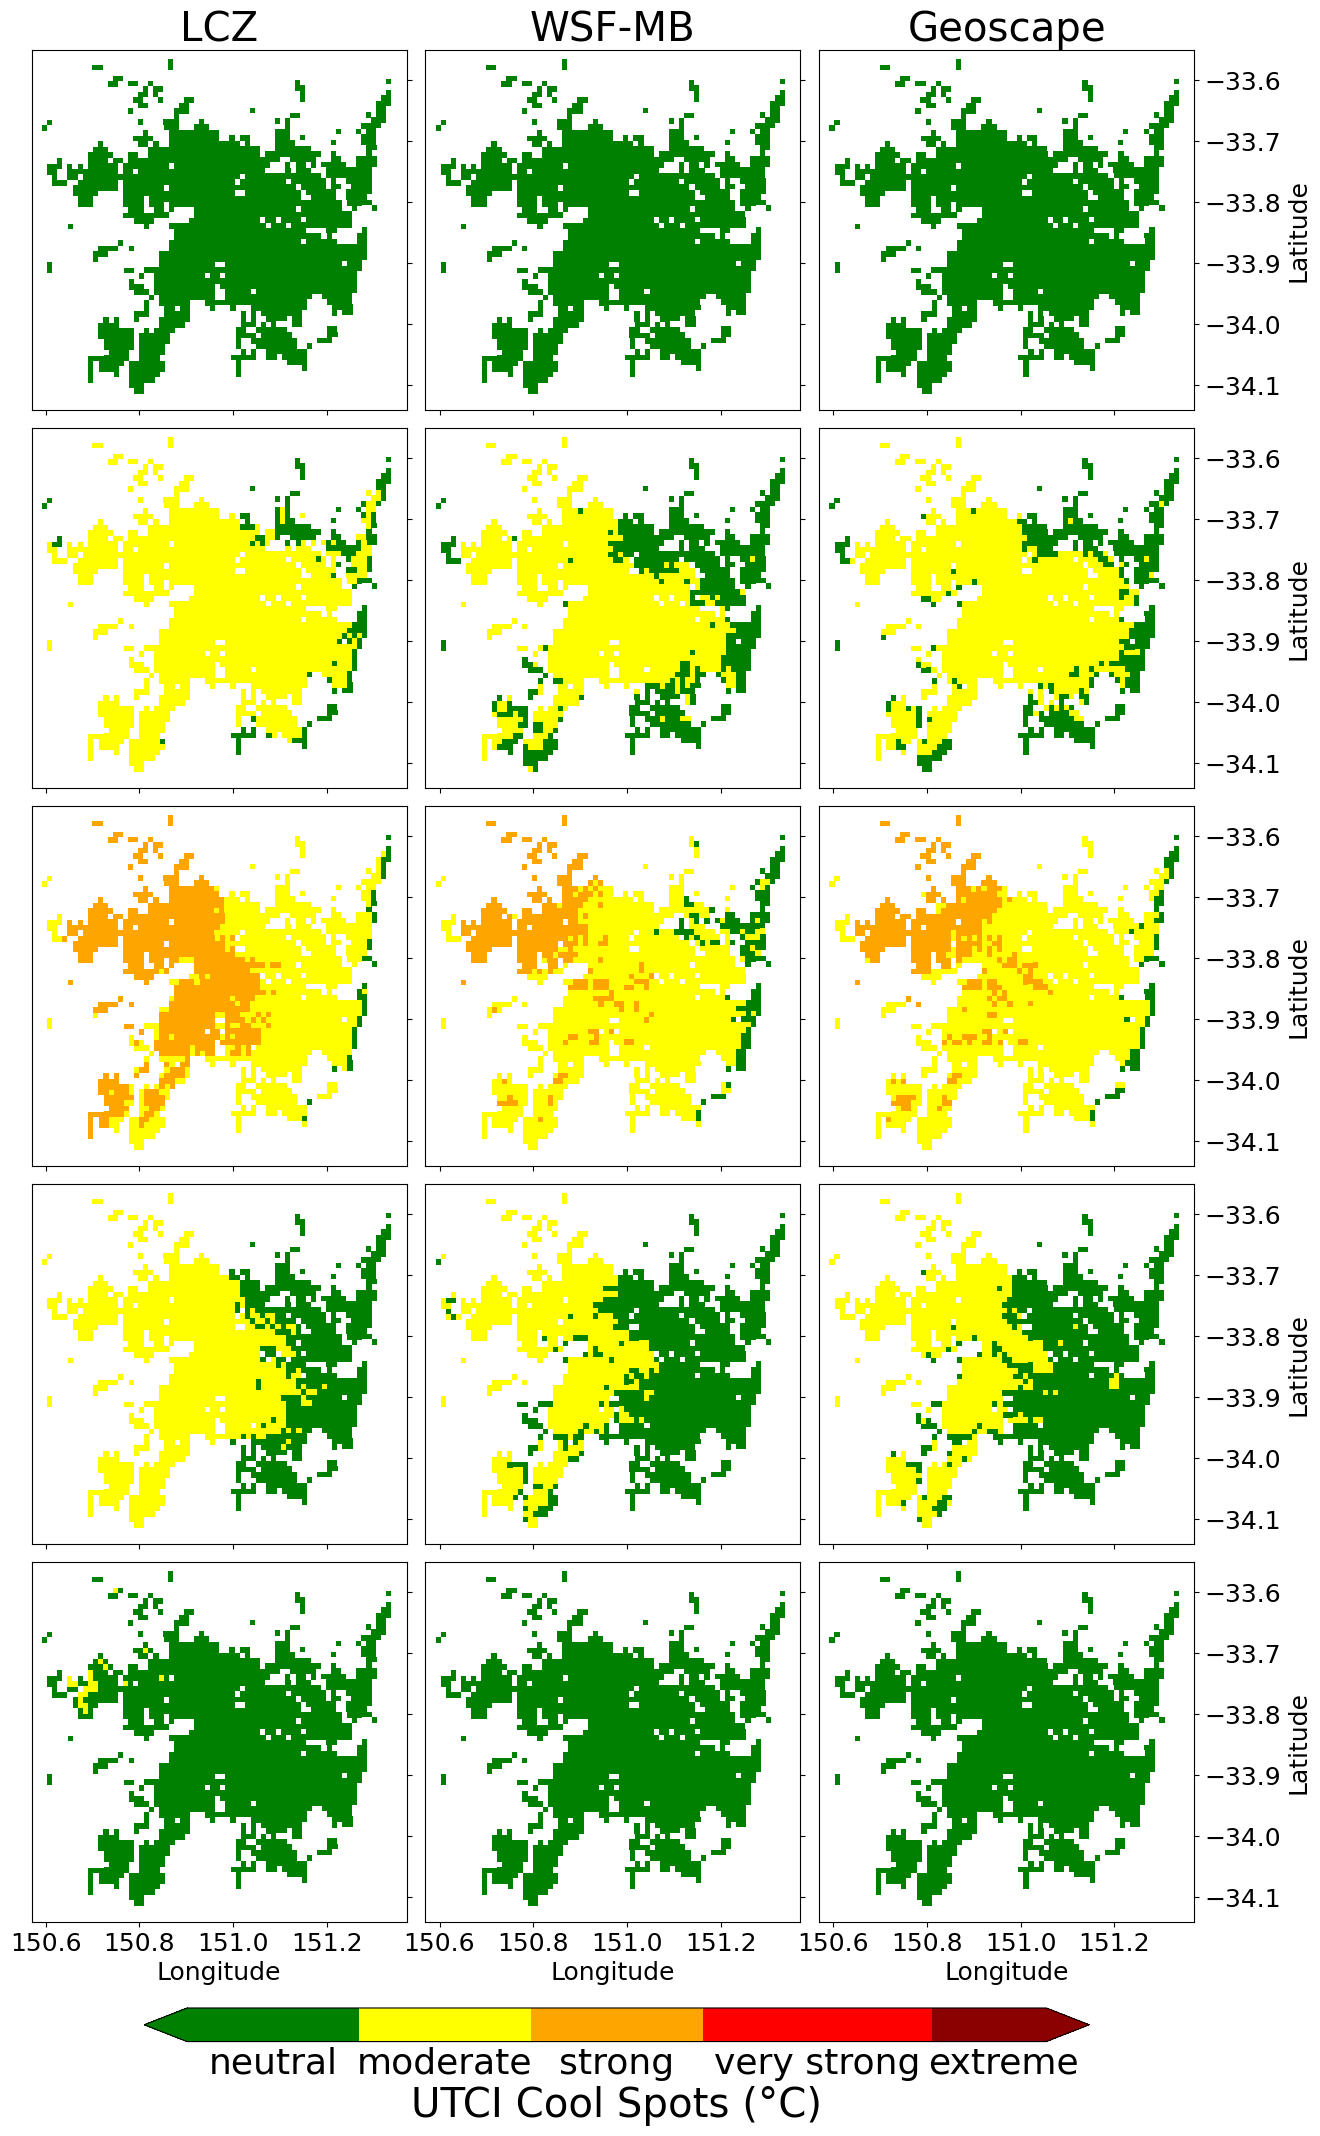

In [ ]:
#UTCI cool spots/COMF10 with stress categories - Figure 10

#custom colorbar
# Define the temperature boundaries and corresponding colors
boundaries = [20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50]
colors = ['green', 'green', 'green', 'yellow', 'yellow', 'yellow', 'orange', 'orange', 'orange', 'red', 'red', 'red', 'red', 'darkred', 'darkred']

# Using ListedColormap for discrete colors
def create_utci_colormap_discrete():
    """Create a discrete colormap with sharp boundaries between colors"""
    cmap = mcolors.ListedColormap(colors)
    norm = mcolors.BoundaryNorm(boundaries, cmap.N)
    return cmap, norm
# Get the colormap
utci_cmap, utci_norm = create_utci_colormap_discrete()

# Define scenarios and periods
scenarios = ["LCZ", "WSF-MB", "Geoscape"]
periods = ["bsr", "morning", "peak", "aft", "eve"]
period_labels = {
    "bsr": "Before Sunrise (2-5)",
    "morning": "Morning (7-10)", 
    "peak": "Peak Solar (11-14)",
    "aft": "Afternoon (15-18)",
    "eve": "Evening (19-22)"
}

lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

# Set up figure with 5x3 subplots
fig, axs = plt.subplots(5, 3, figsize=(15, 24), sharex=True, sharey=True, constrained_layout=False)

# Plot data
for row, period in enumerate(periods):
    for col, scenario in enumerate(scenarios):
        ax = axs[row, col]
        
        # Get data for this period and scenario
        data = results[scenario][period]["COMF10"].where(region_mask)
        
        # Plot
        im = data.plot(
            ax=ax,
            x='XLONG',
            y='XLAT',
            cmap=utci_cmap,
            norm=utci_norm,
            add_colorbar=False
        )
        
        # Set limits
        ax.set_ylim(lat_min, lat_max)
        ax.set_xlim(lon_min, lon_max)
        
        # Labels and titles
        if row == 0:  # Top row - add scenario names
            ax.set_title(scenario, fontsize=29)  #, fontweight='bold'
        else:
            ax.set_title("")
            
        #if col == 0:  # Left column - add period labels
          #  ax.text(-0.05, 0.5, period_labels[period], transform=ax.transAxes, 
           #        fontsize=29, rotation=90, #fontweight='bold', 
           #        verticalalignment='center', horizontalalignment='center')
        
        # X and Y labels only on edges
        if row == len(periods) - 1:  # Bottom row
            ax.set_xlabel("Longitude", fontsize=18)
        else:
            ax.set_xlabel("")
            
        if col == 2:  # Left column
            ax.set_ylabel("Latitude", fontsize=18)
        else:
            ax.set_ylabel("")
            
        # Remove tick labels except on edges
        if row != len(periods) - 1:  # Not bottom row
            ax.tick_params(labelbottom=False)
        if col != 2:  # Not left column
            ax.tick_params(labelleft=False)
        else:
            ax.tick_params(labelleft=True)

        ax.tick_params(axis='both', which='major', labelsize=18)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

# Add single horizontal colorbar at bottom spanning all columns
cax = fig.add_axes([0.2, 0.05, 0.63, 0.014])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', 
                   pad=0.02, shrink=0.8, aspect=40, ticks=boundaries, extend='both')
cbar.set_label("UTCI Cool Spots (°C)", fontsize=29)
cbar.set_ticklabels(boundaries)
tick_locations = [23, 29, 35, 42, 48.5]
tick_labels = ['neutral', 'moderate', 'strong', 'very strong', 'extreme']
cbar.set_ticks(tick_locations)
cbar.set_ticklabels(tick_labels)
cbar.ax.minorticks_off()
cbar.ax.tick_params(size=0, labelsize=26)
fig.subplots_adjust(wspace=0.05, hspace=0.05, bottom=0.1)

plt.savefig("COMF10avg-5x3-all_periods_stresscats.png", 
           bbox_inches='tight', dpi=300)
plt.show()

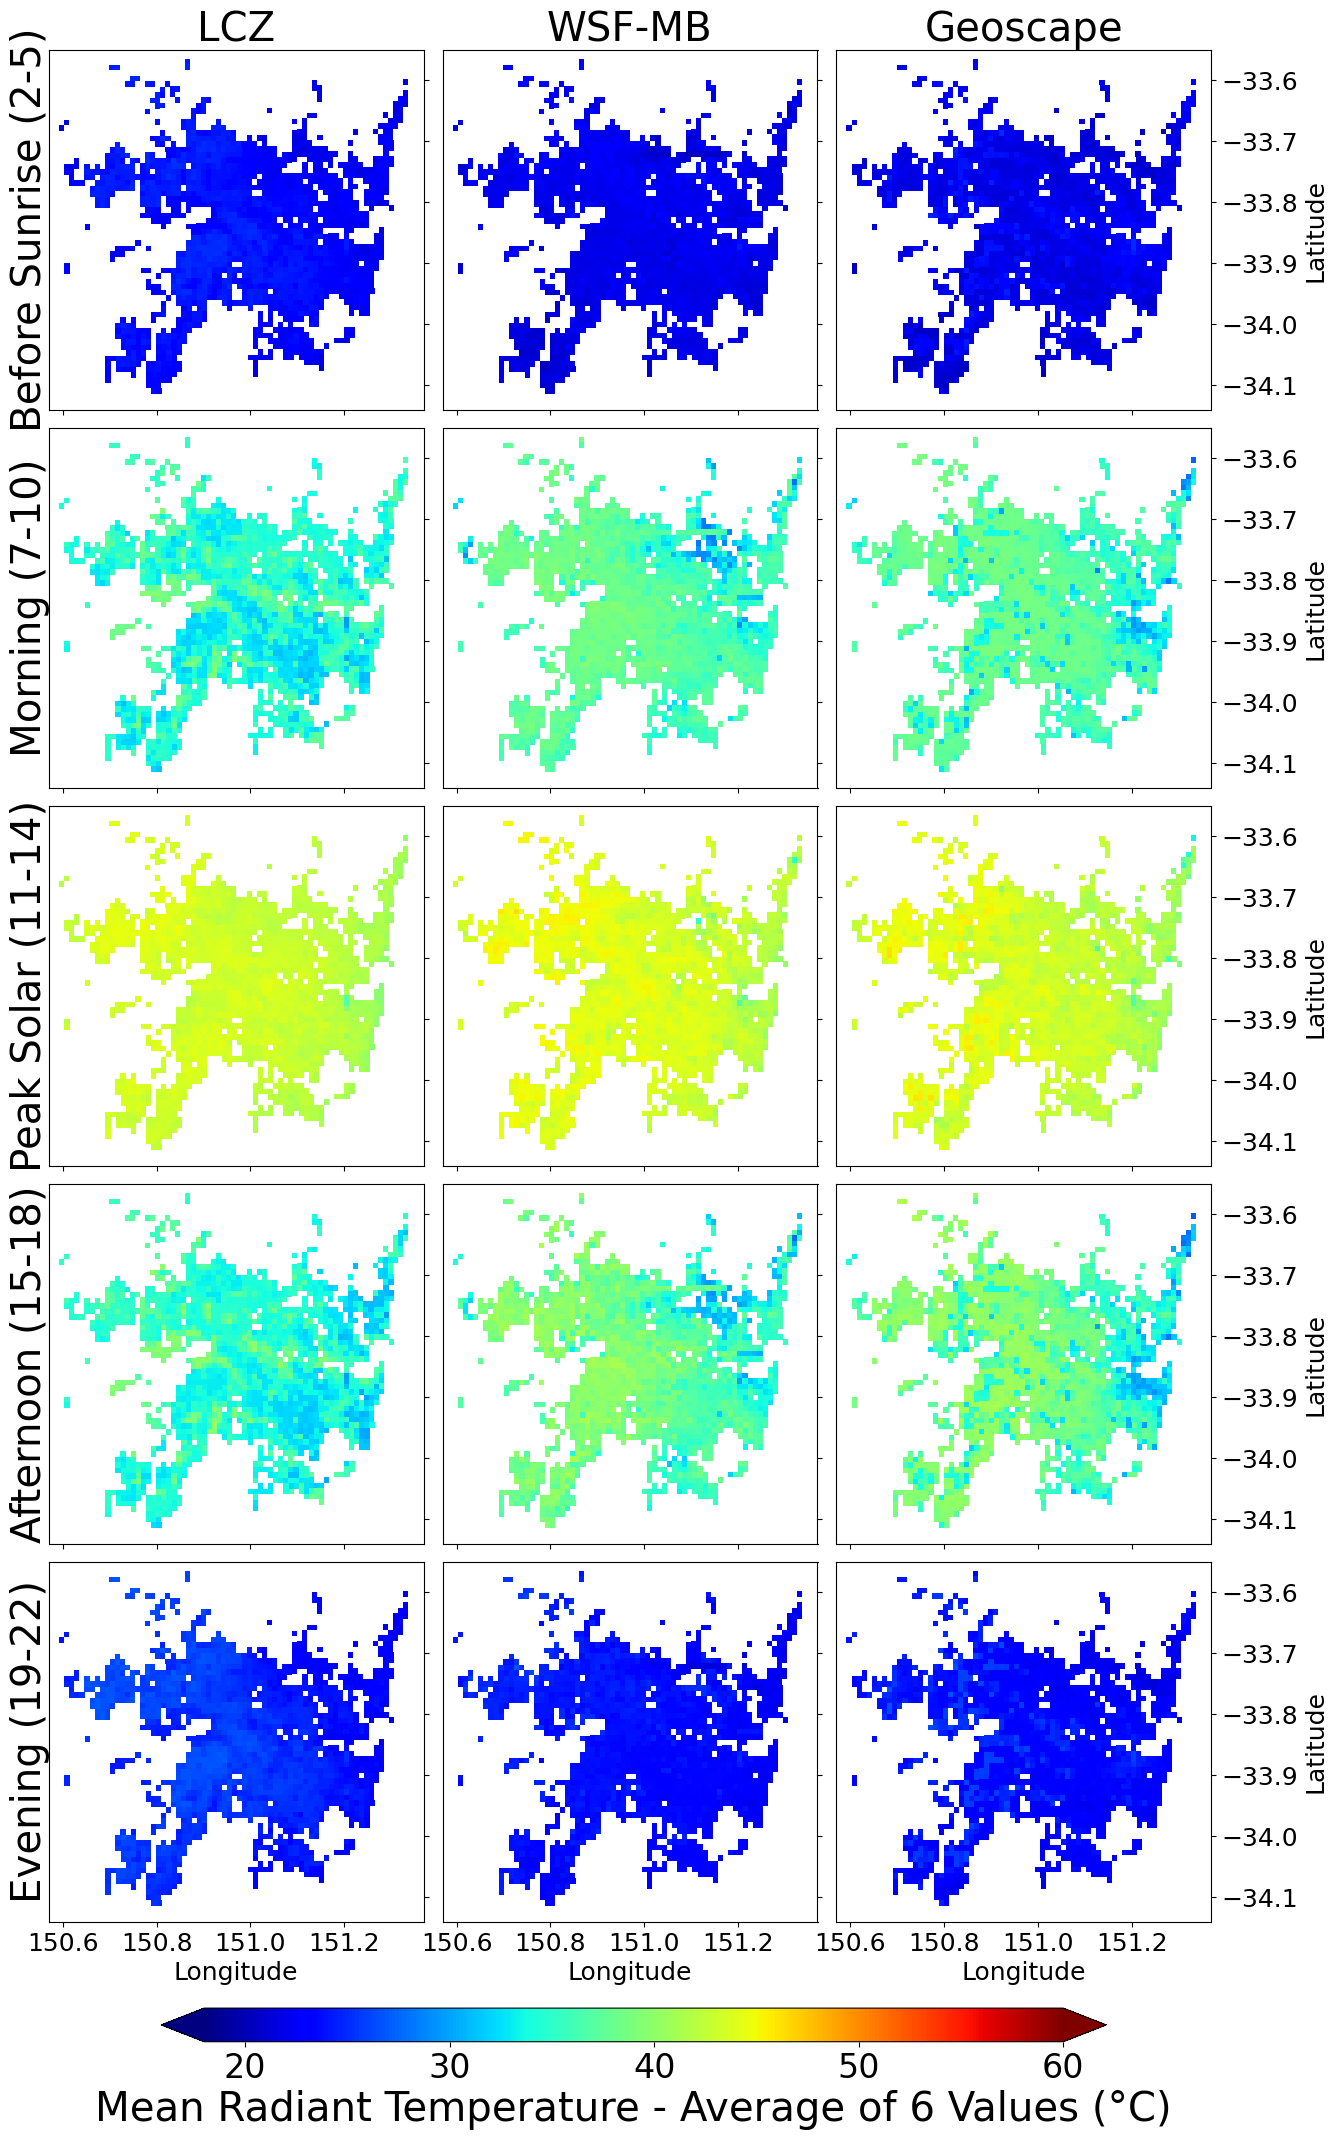

In [ ]:
#MRT (mean of the 6 values) - Figure S14

# Define scenarios and periods
scenarios = ["LCZ", "WSF-MB", "Geoscape"]
periods = ["bsr", "morning", "peak", "aft", "eve"]
period_labels = {
    "bsr": "Before Sunrise (2-5)",
    "morning": "Morning (7-10)", 
    "peak": "Peak Solar (11-14)",
    "aft": "Afternoon (15-18)",
    "eve": "Evening (19-22)"
}

lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

# Set up figure with 5x3 subplots
fig, axs = plt.subplots(5, 3, figsize=(15, 24), sharex=True, sharey=True, constrained_layout=False)

# Plot data
for row, period in enumerate(periods):
    for col, scenario in enumerate(scenarios):
        ax = axs[row, col]
        
        # Get data for this period and scenario
        data = results[scenario][period]["TMR_mean"].where(region_mask) -273.15
        
        # Plot
        im = data.plot(
            ax=ax,
            x='XLONG',
            y='XLAT',
            cmap='jet',
            vmin=18,
            vmax=60, #45
            add_colorbar=False
        )
        
        # Set limits
        ax.set_ylim(lat_min, lat_max)
        ax.set_xlim(lon_min, lon_max)
         
        # Labels and titles
        if row == 0:  # Top row - add scenario names
            ax.set_title(scenario, fontsize=29)  #, fontweight='bold'
        else:
            ax.set_title("")
            
        if col == 0:  # Left column - add period labels
            ax.text(-0.05, 0.5, period_labels[period], transform=ax.transAxes, 
                   fontsize=29, rotation=90, #fontweight='bold', 
                   verticalalignment='center', horizontalalignment='center')
        
        # X and Y labels only on edges
        if row == len(periods) - 1:  # Bottom row
            ax.set_xlabel("Longitude", fontsize=18)
        else:
            ax.set_xlabel("")
            
        if col == 2:  # Left column
            ax.set_ylabel("Latitude", fontsize=18)
        else:
            ax.set_ylabel("")
            
        # Remove tick labels except on edges
        if row != len(periods) - 1:  # Not bottom row
            ax.tick_params(labelbottom=False)
        if col != 2:  # Not left column
            ax.tick_params(labelleft=False)
        else:
            ax.tick_params(labelleft=True)

        ax.tick_params(axis='both', which='major', labelsize=18)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

# Add colorbar
cax = fig.add_axes([0.2, 0.05, 0.63, 0.014])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', extend='both')
cbar.ax.tick_params(labelsize=24)
cbar.set_label("Mean Radiant Temperature - Average of 6 Values (°C)", fontsize=29)
fig.subplots_adjust(wspace=0.05, hspace=0.05, bottom=0.1)

plt.savefig("TMRavg-5x3-all_periods.png", 
           bbox_inches='tight', dpi=300)
plt.show()

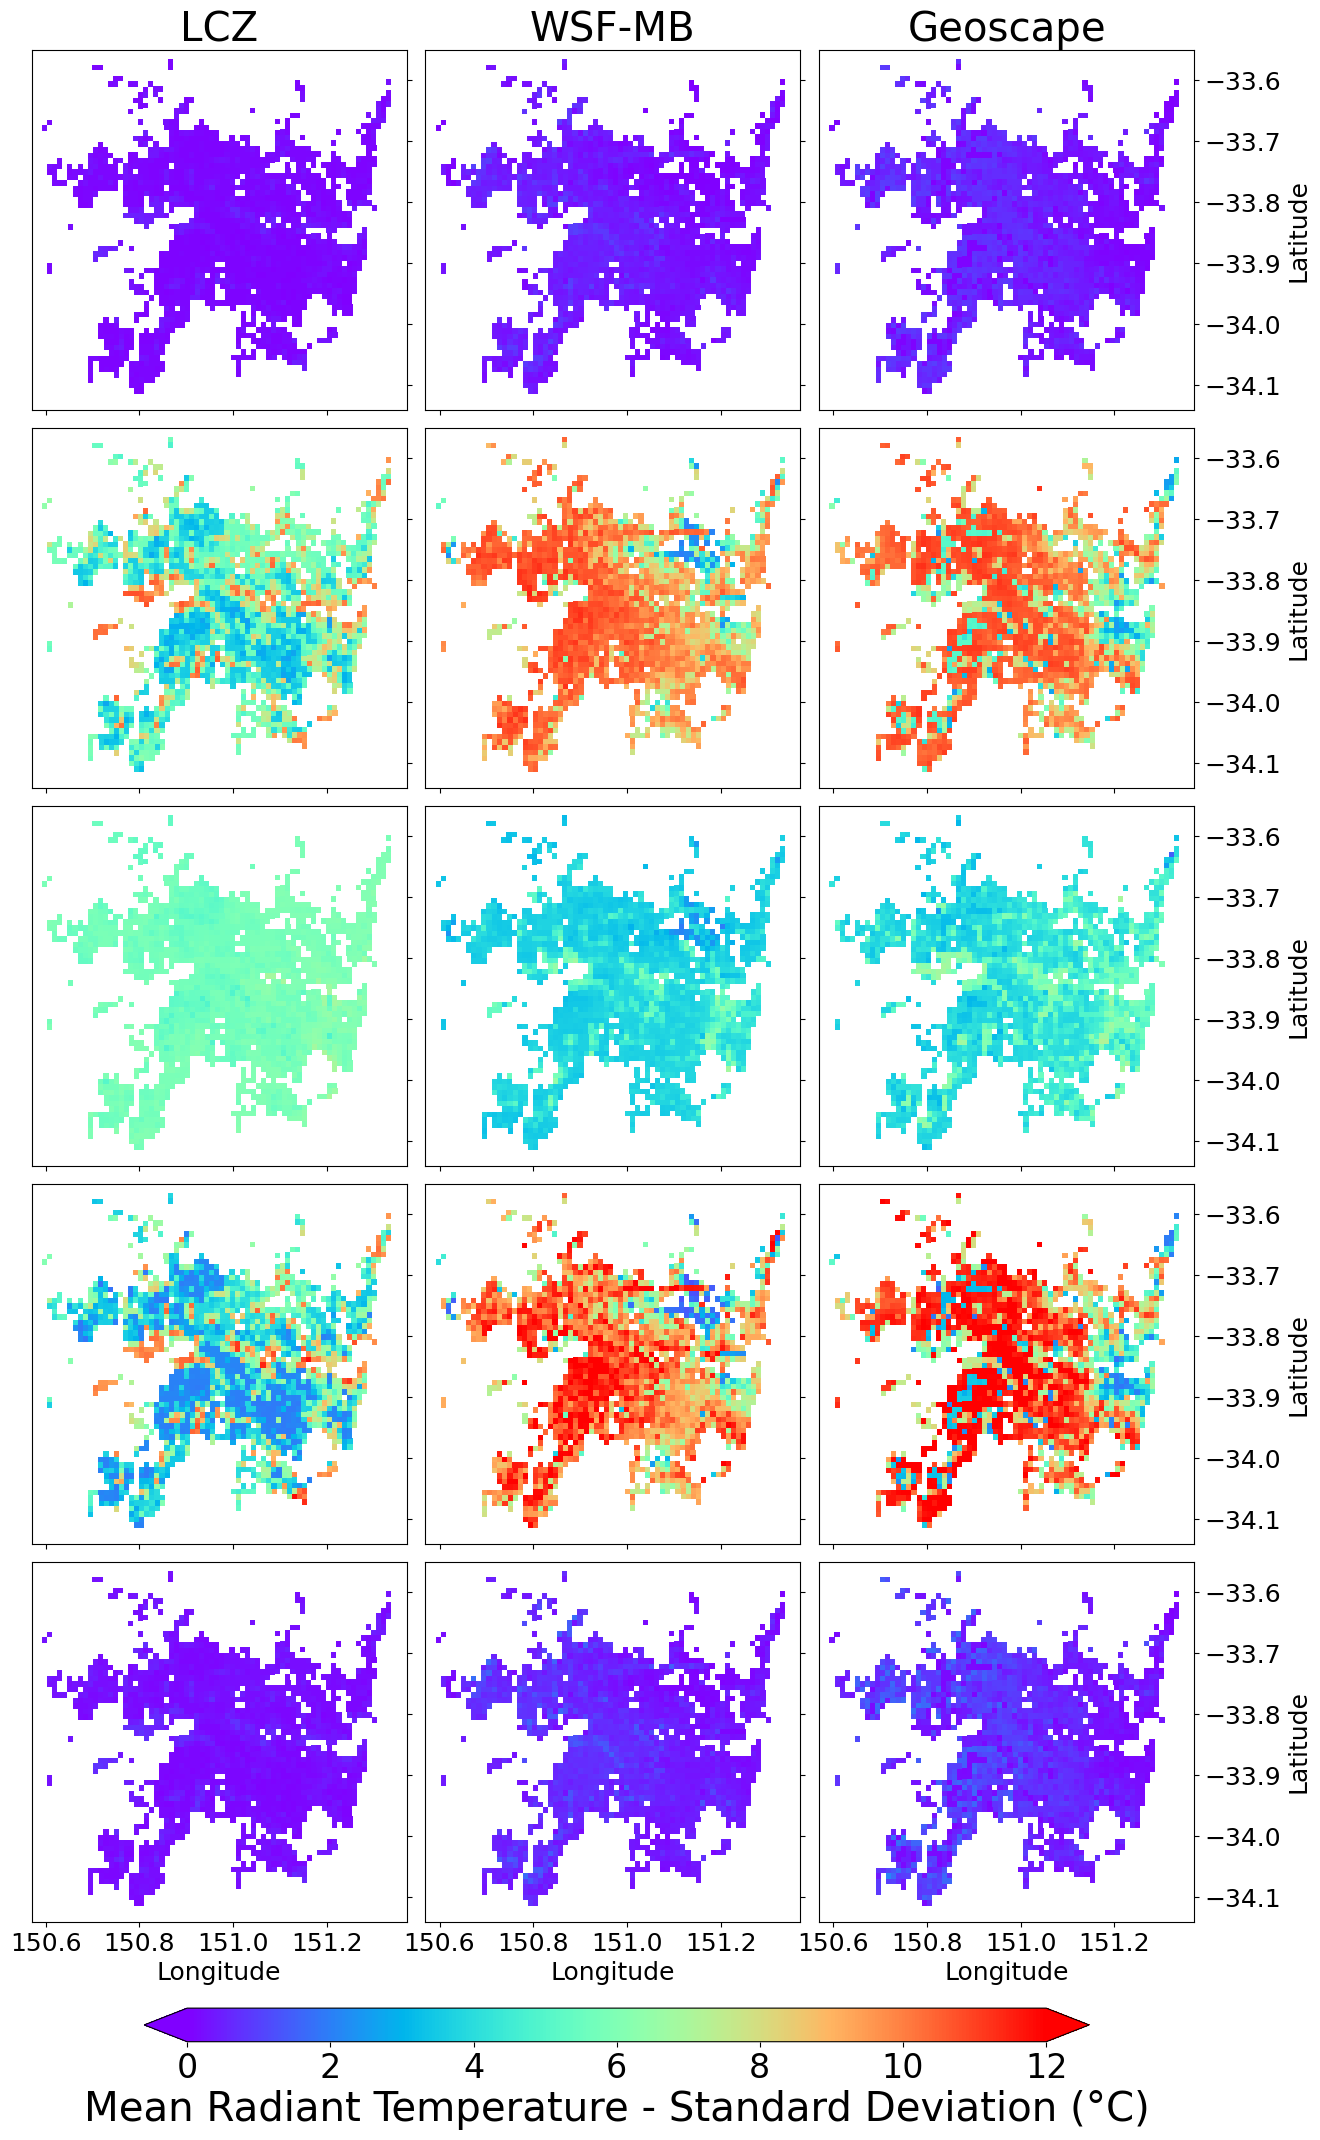

In [ ]:
#MRT standard deviation - Figure S14

# Define scenarios and periods
scenarios = ["LCZ", "WSF-MB", "Geoscape"]
periods = ["bsr", "morning", "peak", "aft", "eve"]
period_labels = {
    "bsr": "Before Sunrise (2-5)",
    "morning": "Morning (7-10)", 
    "peak": "Peak Solar (11-14)",
    "aft": "Afternoon (15-18)",
    "eve": "Evening (19-22)"
}

lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

# Set up figure with 5x3 subplots
fig, axs = plt.subplots(5, 3, figsize=(15, 24), sharex=True, sharey=True, constrained_layout=False)

# Plot data
for row, period in enumerate(periods):
    for col, scenario in enumerate(scenarios):
        ax = axs[row, col]
        
        # Get data for this period and scenario
        data = results[scenario][period]["TMR_std"].where(region_mask) 
        
        # Plot
        im = data.plot(
            ax=ax,
            x='XLONG',
            y='XLAT',
            cmap='rainbow',
            vmin=0,
            vmax=12,
            add_colorbar=False
        )
        
        # Set limits
        ax.set_ylim(lat_min, lat_max)
        ax.set_xlim(lon_min, lon_max)
        
        
        # Labels and titles
        if row == 0:  # Top row - add scenario names
            ax.set_title(scenario, fontsize=29)  #, fontweight='bold'
        else:
            ax.set_title("")
            
        #if col == 0:  # Left column - add period labels
            #ax.text(-0.05, 0.5, period_labels[period], transform=ax.transAxes, 
              #     fontsize=29, rotation=90, #fontweight='bold', 
              #     verticalalignment='center', horizontalalignment='center')
        
        # X and Y labels only on edges
        if row == len(periods) - 1:  # Bottom row
            ax.set_xlabel("Longitude", fontsize=18)
        else:
            ax.set_xlabel("")
            
        if col == 2:  # Left column
            ax.set_ylabel("Latitude", fontsize=18)
        else:
            ax.set_ylabel("")
            
        # Remove tick labels except on edges
        if row != len(periods) - 1:  # Not bottom row
            ax.tick_params(labelbottom=False)
        if col != 2:  # Not left column
            ax.tick_params(labelleft=False)
        else:
            ax.tick_params(labelleft=True)

        ax.tick_params(axis='both', which='major', labelsize=18)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

# Add colorbar
cax = fig.add_axes([0.2, 0.05, 0.63, 0.014])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', extend='both')
cbar.ax.tick_params(labelsize=24)
cbar.set_label("Mean Radiant Temperature - Standard Deviation (°C)", fontsize=29)
fig.subplots_adjust(wspace=0.05, hspace=0.05, bottom=0.1)

plt.savefig("TMRstd-5x3-all_periods.png", 
           bbox_inches='tight', dpi=300)
plt.show()

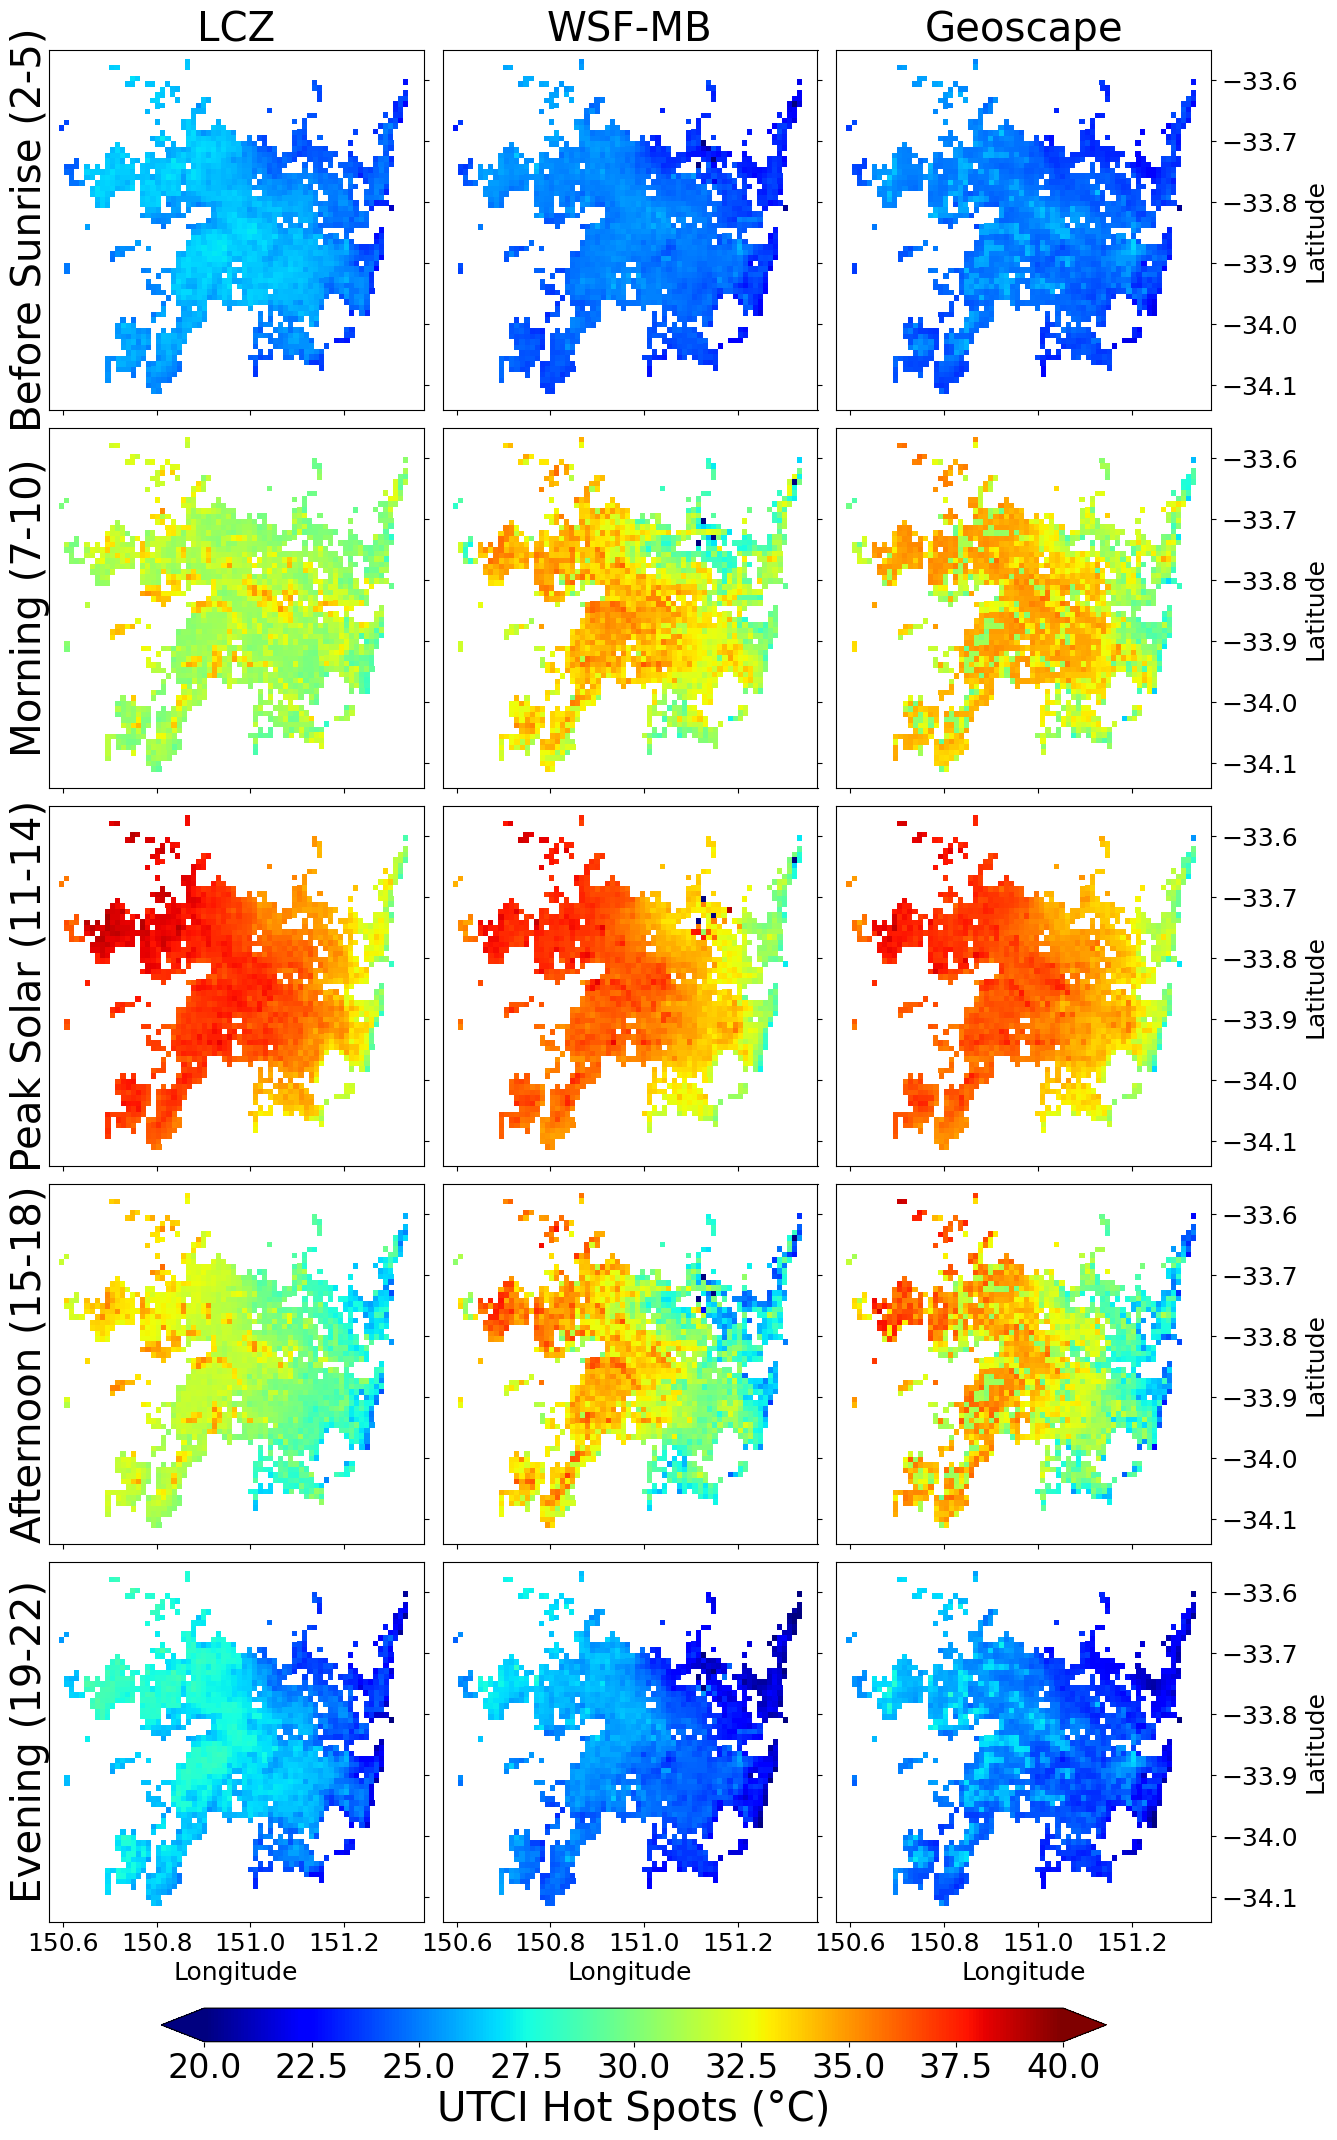

In [ ]:
#UTCI hot spots/COMF90 with values in °C - Fugure S16

# Define scenarios and periods
scenarios = ["LCZ", "WSF-MB", "Geoscape"]
periods = ["bsr", "morning", "peak", "aft", "eve"]
period_labels = {
    "bsr": "Before Sunrise (2-5)",
    "morning": "Morning (7-10)", 
    "peak": "Peak Solar (11-14)",
    "aft": "Afternoon (15-18)",
    "eve": "Evening (19-22)"
}

lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

# Set up figure with 5x3 subplots
fig, axs = plt.subplots(5, 3, figsize=(15, 24), sharex=True, sharey=True, constrained_layout=False)

# Plot data
for row, period in enumerate(periods):
    for col, scenario in enumerate(scenarios):
        ax = axs[row, col]
        
        # Get data for this period and scenario
        data = results[scenario][period]["COMF90"].where(region_mask)
        
        # Plot
        im = data.plot(
            ax=ax,
            x='XLONG',
            y='XLAT',
            cmap='jet',
            vmin=20,#22,
            vmax=40, #38,
            add_colorbar=False
        )
        
        # Set limits
        ax.set_ylim(lat_min, lat_max)
        ax.set_xlim(lon_min, lon_max)
                
        # Labels and titles
        if row == 0:  # Top row - add scenario names
            ax.set_title(scenario, fontsize=29)  #, fontweight='bold'
        else:
            ax.set_title("")
            
        if col == 0:  # Left column - add period labels
            ax.text(-0.05, 0.5, period_labels[period], transform=ax.transAxes, 
                   fontsize=29, rotation=90, #fontweight='bold', 
                   verticalalignment='center', horizontalalignment='center')
        
        # X and Y labels only on edges
        if row == len(periods) - 1:  # Bottom row
            ax.set_xlabel("Longitude", fontsize=18)
        else:
            ax.set_xlabel("")
            
        if col == 2:  # Left column
            ax.set_ylabel("Latitude", fontsize=18)
        else:
            ax.set_ylabel("")
            
        # Remove tick labels except on edges
        if row != len(periods) - 1:  # Not bottom row
            ax.tick_params(labelbottom=False)
        if col != 2:  # Not left column
            ax.tick_params(labelleft=False)
        else:
            ax.tick_params(labelleft=True)

        ax.tick_params(axis='both', which='major', labelsize=18)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

# Add colorbar
cax = fig.add_axes([0.2, 0.05, 0.63, 0.014])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', extend='both')
cbar.ax.tick_params(labelsize=24)
cbar.set_label("UTCI Hot Spots (°C)", fontsize=29)
fig.subplots_adjust(wspace=0.05, hspace=0.05, bottom=0.1)

plt.savefig("COMF90avg-5x3-all_periods.png", 
           bbox_inches='tight', dpi=300)
plt.show()

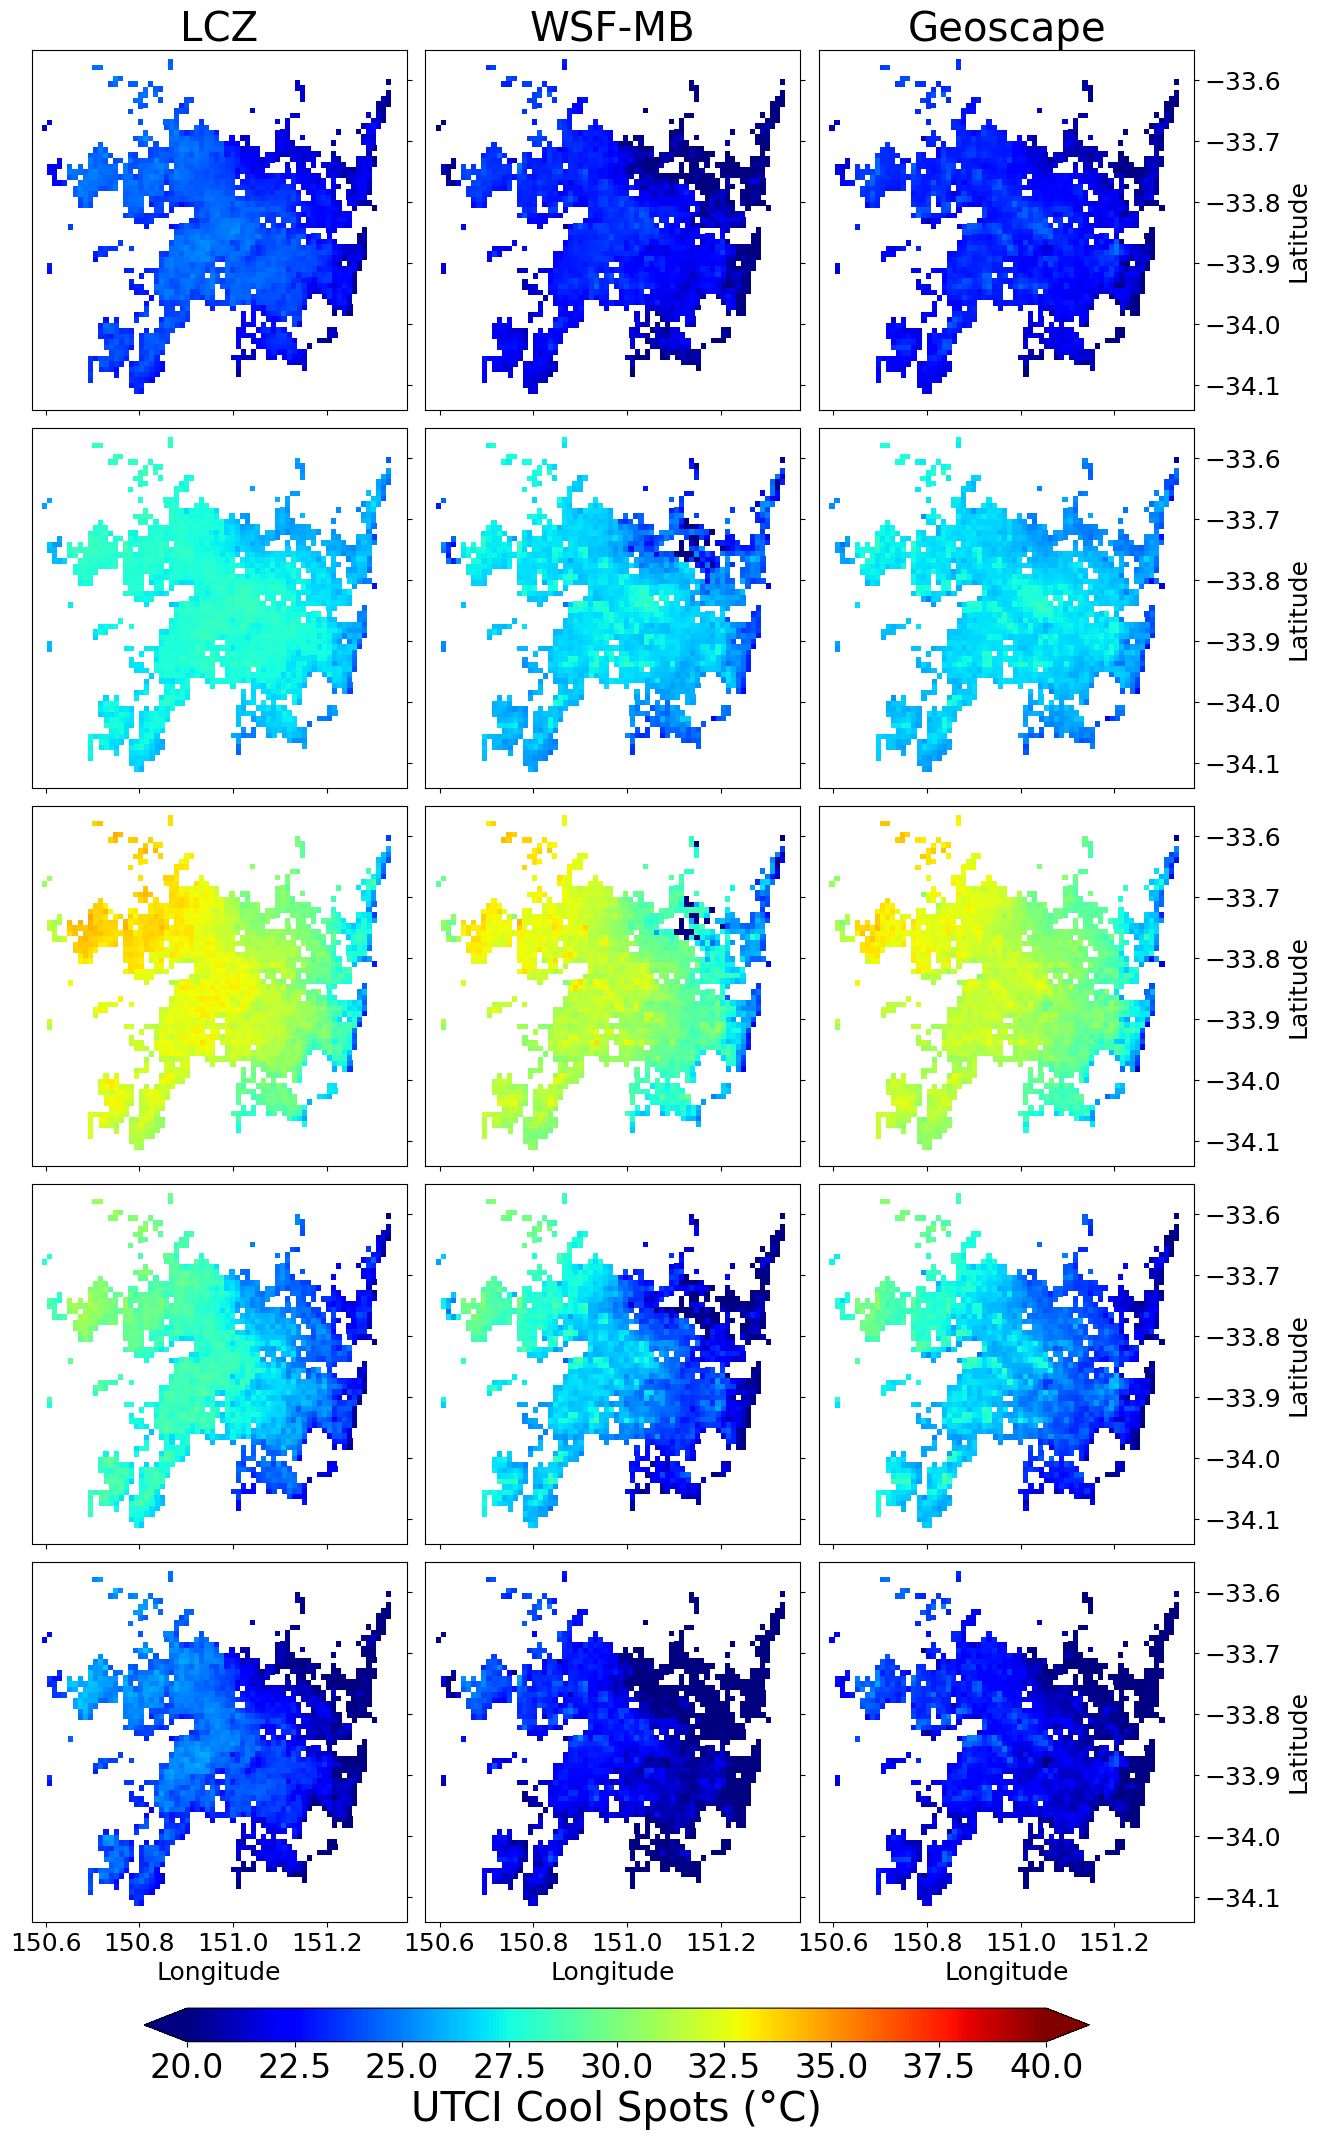

In [ ]:
#UTCI cool spots/COMF10 with values in °C - Fugure S16

# Define scenarios and periods
scenarios = ["LCZ", "WSF-MB", "Geoscape"]
periods = ["bsr", "morning", "peak", "aft", "eve"]
period_labels = {
    "bsr": "Before Sunrise (2-5)",
    "morning": "Morning (7-10)", 
    "peak": "Peak Solar (11-14)",
    "aft": "Afternoon (15-18)",
    "eve": "Evening (19-22)"
}

lat_min, lat_max = -34.14, -33.55
lon_min, lon_max = 150.57, 151.37

# Set up figure with 5x3 subplots
fig, axs = plt.subplots(5, 3, figsize=(15, 24), sharex=True, sharey=True, constrained_layout=False)

# Plot data
for row, period in enumerate(periods):
    for col, scenario in enumerate(scenarios):
        ax = axs[row, col]
        
        # Get data for this period and scenario
        data = results[scenario][period]["COMF10"].where(region_mask)
        
        # Plot
        im = data.plot(
            ax=ax,
            x='XLONG',
            y='XLAT',
            cmap='jet',
            vmin=20,  #18,
            vmax=40,   #34,
            add_colorbar=False
        )
        
        # Set limits
        ax.set_ylim(lat_min, lat_max)
        ax.set_xlim(lon_min, lon_max)
         
        # Labels and titles
        if row == 0:  # Top row - add scenario names
            ax.set_title(scenario, fontsize=29)  #, fontweight='bold'
        else:
            ax.set_title("")
            
        #if col == 0:  # Left column - add period labels
            #ax.text(-0.05, 0.5, period_labels[period], transform=ax.transAxes, 
              #     fontsize=29, rotation=90, #fontweight='bold', 
              #     verticalalignment='center', horizontalalignment='center')
        
        # X and Y labels only on edges
        if row == len(periods) - 1:  # Bottom row
            ax.set_xlabel("Longitude", fontsize=18)
        else:
            ax.set_xlabel("")
            
        if col == 2:  # Left column
            ax.set_ylabel("Latitude", fontsize=18)
        else:
            ax.set_ylabel("")
            
        # Remove tick labels except on edges
        if row != len(periods) - 1:  # Not bottom row
            ax.tick_params(labelbottom=False)
        if col != 2:  # Not left column
            ax.tick_params(labelleft=False)
        else:
            ax.tick_params(labelleft=True)

        ax.tick_params(axis='both', which='major', labelsize=18)
        ax.yaxis.tick_right()
        ax.yaxis.set_label_position("right")

# Add colorbar
cax = fig.add_axes([0.2, 0.05, 0.63, 0.014])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', extend='both')
cbar.ax.tick_params(labelsize=24)
cbar.set_label("UTCI Cool Spots (°C)", fontsize=29)
fig.subplots_adjust(wspace=0.05, hspace=0.05, bottom=0.1)

plt.savefig("COMF10avg-5x3-all_periods.png", 
           bbox_inches='tight', dpi=300)
plt.show()